In [1]:
!pip install keras_preprocessing


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from keras.utils import to_categorical
from keras_preprocessing.image import load_img
from keras.models import Sequential
from keras.layers import Dense,Conv2D,Dropout,Flatten,MaxPooling2D
import os
import pandas as pd
import numpy as np

In [3]:
TRAIN_DIR=r"C:\Users\Aswin Kumar Nayak\OneDrive\Documents\project1 opencv(mood detection\images\train"
TEST_DIR=r"C:\Users\Aswin Kumar Nayak\OneDrive\Documents\project1 opencv(mood detection\images\test"

In [4]:

print(os.path.exists(TRAIN_DIR))  # This should return True if the path is correct


True


In [5]:
def createdataframe(dir):
    image_paths=[]
    labels=[]
    for label in os.listdir(dir):
        for imagename in os.listdir(os.path.join(dir,label)):
            image_paths.append(os.path.join(dir,label,imagename))
            labels.append(label)
        print(label,"Completed")
    return image_paths,labels

In [6]:
train=pd.DataFrame()
train['image'],train['label']=createdataframe(TRAIN_DIR)

angry Completed
disgust Completed
fear Completed
happy Completed
neutral Completed
sad Completed
surprise Completed


In [7]:
print(train)

                                                   image     label
0      C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...     angry
1      C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...     angry
2      C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...     angry
3      C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...     angry
4      C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...     angry
...                                                  ...       ...
28816  C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...  surprise
28817  C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...  surprise
28818  C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...  surprise
28819  C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...  surprise
28820  C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...  surprise

[28821 rows x 2 columns]


In [8]:
test=pd.DataFrame()
test['image'],test['label']=createdataframe(TEST_DIR)

angry Completed
disgust Completed
fear Completed
happy Completed
neutral Completed
sad Completed
surprise Completed


In [9]:
print(test)

                                                  image     label
0     C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...     angry
1     C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...     angry
2     C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...     angry
3     C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...     angry
4     C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...     angry
...                                                 ...       ...
7061  C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...  surprise
7062  C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...  surprise
7063  C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...  surprise
7064  C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...  surprise
7065  C:\Users\Aswin Kumar Nayak\OneDrive\Documents\...  surprise

[7066 rows x 2 columns]


In [10]:
from tqdm.notebook import tqdm


In [11]:
!pip install Pillow



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
pip install --upgrade --force-reinstall Pillow


  Using cached pillow-11.0.0-cp311-cp311-win_amd64.whl.metadata (9.3 kB)
Using cached pillow-11.0.0-cp311-cp311-win_amd64.whl (2.6 MB)
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.0.0
    Uninstalling pillow-11.0.0:
      Successfully uninstalled pillow-11.0.0
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
pip install --upgrade keras_preprocessing


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
def extract_features(images):
    features=[]
    for image in tqdm(images):
        img=load_img(image,color_mode="grayscale")
        img=np.array(img)
        features.append(img)
    features=np.array(features)
    features=features.reshape(len(features),48,48,1)
    return features

In [15]:
train_features=extract_features(train['image'])

  0%|          | 0/28821 [00:00<?, ?it/s]

In [16]:
test_features=extract_features(test['image'])

  0%|          | 0/7066 [00:00<?, ?it/s]

In [17]:
x_train=train_features/255.0
x_test=test_features/255.0

In [18]:
!pip install scikit-learn



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
from sklearn.preprocessing import LabelEncoder


In [20]:
le=LabelEncoder()
le.fit(train['label'])

LabelEncoder()

In [21]:
y_train=le.transform(train['label'])
y_test=le.transform(test['label'])

In [22]:
y_train=to_categorical(y_train,num_classes=7)
y_test=to_categorical(y_test,num_classes=7)

In [23]:
 model=Sequential()
#Convolutional layers
model.add(Conv2D(128,kernel_size=(3,3),activation='relu',input_shape=(48,48,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(256,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Flatten())
#fully connected layers
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.3))
#output layer
model.add(Dense(7,activation='softmax'))



C:\Users\Aswin Kumar Nayak\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [25]:
model.fit(x=x_train,y=y_train,batch_size=128,epochs=100,validation_data=(x_test,y_test))

Epoch 1/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 188s 821ms/step - accuracy: 0.2395 - loss: 1.8343 - val_accuracy: 0.2583 - val_loss: 1.8109
Epoch 2/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 183s 811ms/step - accuracy: 0.2502 - loss: 1.8112 - val_accuracy: 0.2577 - val_loss: 1.7874
Epoch 3/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 190s 842ms/step - accuracy: 0.2666 - loss: 1.7679 - val_accuracy: 0.3409 - val_loss: 1.6483
Epoch 4/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 189s 836ms/step - accuracy: 0.3365 - loss: 1.6644 - val_accuracy: 0.4216 - val_loss: 1.4793
Epoch 5/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 180s 796ms/step - accuracy: 0.4044 - loss: 1.5309 - val_accuracy: 0.4639 - val_loss: 1.3784
Epoch 6/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 182s 804ms/step - accuracy: 0.4349 - loss: 1.4571 - val_accuracy: 0.4853 - val_loss: 1.3320
Epoch 7/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 180s 799ms/step - accuracy: 0.4558 - loss: 1.4178 - val_accuracy: 0.5125 - val_loss: 1.2936
Epoch 8/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 181s 802ms/step - accuracy: 

KeyboardInterrupt: 

In [26]:
model_json=model.to_json()
with open("emotiondetector.json",'w') as json_file:
    json_file.write(model_json)
model.save("emotiondetector.h5")

In [27]:
from keras.models import model_from_json

In [28]:
print(os.getcwd())

C:\Users\Aswin Kumar Nayak\OneDrive\Documents\project1 opencv(mood detection


In [29]:
if os.path.exists("facialemotionmodel.json"):
    json_file = open("facialemotionmodel.json", "r")
    model_json = json_file.read()
    json_file.close()
    print("exist")
else:
    print("The file facialemotionmodel.json does not exist.")

exist


In [30]:
model_json = model.to_json()  # Get the model architecture as a JSON string
with open("facialemotionmodel.json", "w") as json_file:
    json_file.write(model_json)
model.save("facialemotionmodel.h5")

In [31]:
import h5py

try:
    with h5py.File(r"C:\Users\Aswin Kumar Nayak\OneDrive\Documents\project1 opencv(mood detection\facialemotionmodel.h5", 'r') as f:
        print("File is a valid HDF5 file.")
except OSError as e:
    print("Error opening the file:", e)


File is a valid HDF5 file.


In [32]:

print(os.path.exists(r"C:\Users\Aswin Kumar Nayak\OneDrive\Documents\project1 opencv(mood detection\facialemotionmodel.h5"))  # Should return True if the file exists


True


In [33]:
json_file=open(r"C:\Users\Aswin Kumar Nayak\OneDrive\Documents\project1 opencv(mood detection\facialemotionmodel.json","r")
model_json=json_file.read()
json_file.close()
model=model_from_json(model_json)
model.load_weights(r"C:\Users\Aswin Kumar Nayak\OneDrive\Documents\project1 opencv(mood detection\facialemotionmodel.h5")

In [34]:
label=['angry','disgust','fear','happy','neutral','sad','surprise']

In [35]:
def ef(image):
    img=load_img(image,color_mode="grayscale")
    feature=np.array(img)
    feature=feature.reshape(1,48,48,1)
    return feature/255.0
    

In [36]:
image=r"C:\Users\Aswin Kumar Nayak\OneDrive\Documents\project1 opencv(mood detection\images\train\angry\27.jpg"
print("original image is of angry")
img=ef(image)
pred=model.predict(img)
pred_label=label[pred.argmax()]
print("model prediction is",pred_label)

original image is of angry
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
model prediction is angry


In [38]:
!pip install matplotlib


   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/7.8 MB 1.7 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/7.8 MB 1.9 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/7.8 MB 1.9 MB/s eta 0:00:04
   --------- ------------------------------ 1.8/7.8 MB 1.9 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/7.8 MB 1.9 MB/s eta 0:00:04
   ------------- -------------------------- 2.6/7.8 MB 1.9 MB/s eta 0:00:03
   -------------- ------------------------- 2.9/7.8 MB 1.9 MB/s eta 0:00:03
   ----------------- ---------------------- 3.4/7.8 MB 1.9 MB/s eta 0:00:03
   ------------------ --------------------- 3.7/7.8 MB 1.9 MB/s eta 0:00:03
   --------------------- ------------------ 4.2/7.8 MB 2.0 MB/s eta 0:00:02
   ------------------------ --------------- 4.7/7.8 MB 2.0 MB/s eta 0:00:02
   -----------------------


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import matplotlib.pyplot as plt
%matplotlib inline

original image is of sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
model prediction is sad


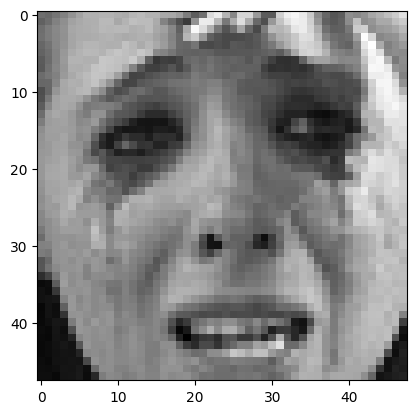

In [43]:
image=r"C:\Users\Aswin Kumar Nayak\OneDrive\Documents\project1 opencv(mood detection\images\train\sad\54.jpg"
print("original image is of sad")
img=ef(image)
pred=model.predict(img)
pred_label=label[pred.argmax()]
print("model prediction is",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
model prediction is happy


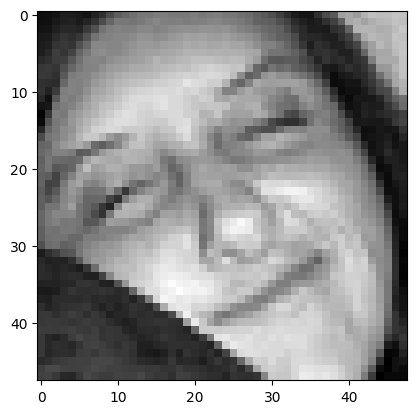

In [44]:
image=r"C:\Users\Aswin Kumar Nayak\OneDrive\Documents\project1 opencv(mood detection\images\train\happy\16.jpg"
print("original image is of happy")
img=ef(image)
pred=model.predict(img)
pred_label=label[pred.argmax()]
print("model prediction is",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of disgust
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
model prediction is disgust


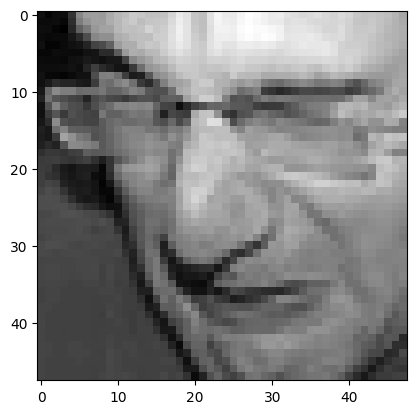

In [45]:
image=r"C:\Users\Aswin Kumar Nayak\OneDrive\Documents\project1 opencv(mood detection\images\train\disgust\473.jpg"
print("original image is of disgust")
img=ef(image)
pred=model.predict(img)
pred_label=label[pred.argmax()]
print("model prediction is",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of fear
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
model prediction is fear


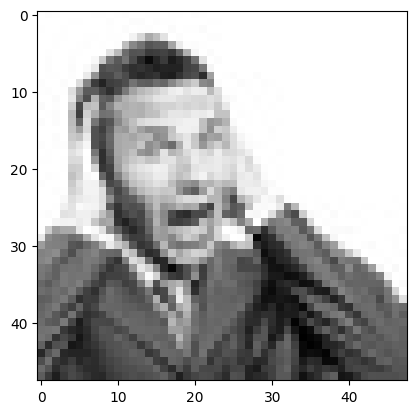

In [46]:
image=r"C:\Users\Aswin Kumar Nayak\OneDrive\Documents\project1 opencv(mood detection\images\train\fear\17.jpg"
print("original image is of fear")
img=ef(image)
pred=model.predict(img)
pred_label=label[pred.argmax()]
print("model prediction is",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of neutral
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
model prediction is neutral


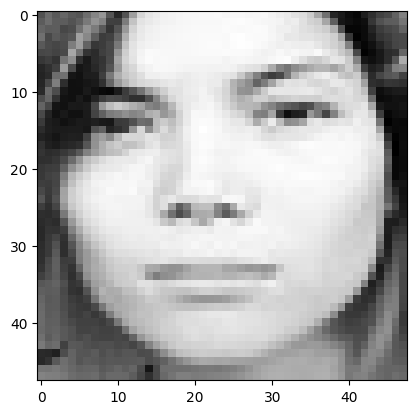

In [47]:
image=r"C:\Users\Aswin Kumar Nayak\OneDrive\Documents\project1 opencv(mood detection\images\train\neutral\35.jpg"
print("original image is of neutral")
img=ef(image)
pred=model.predict(img)
pred_label=label[pred.argmax()]
print("model prediction is",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of surprise
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
model prediction is surprise


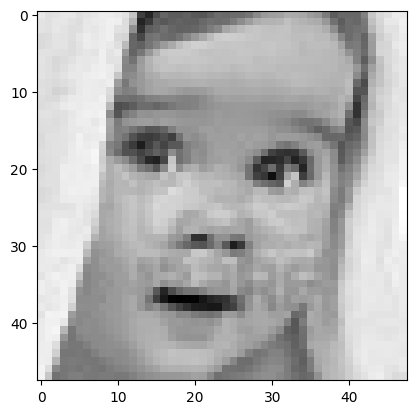

In [48]:
image=r"C:\Users\Aswin Kumar Nayak\OneDrive\Documents\project1 opencv(mood detection\images\train\surprise\52.jpg"
print("original image is of surprise")
img=ef(image)
pred=model.predict(img)
pred_label=label[pred.argmax()]
print("model prediction is",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
model prediction is happy


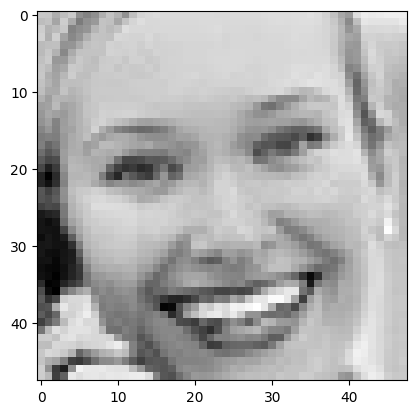

In [50]:
#Test dataset one
image=r"C:\Users\Aswin Kumar Nayak\OneDrive\Documents\project1 opencv(mood detection\images\test\happy\80.jpg"
print("original image is of happy")
img=ef(image)
pred=model.predict(img)
pred_label=label[pred.argmax()]
print("model prediction is",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')